# Gym demo

Demonstrate the use of the the Gym interface

In [ ]:
import numpy as np
import pandas as pd
import torch
print("PyTorch loaded successfully!")

In [ ]:
import pybullet as p
print("PyBullet loaded successfully!")

In [ ]:
import sys
import os
sys.path.extend([os.path.abspath('./assetto_corsa_gym')])
from AssettoCorsaEnv.ac_client import Client
print("Assetto Corsa Client loaded successfully!")

In [1]:
import torch

# 1. Define the path to the model you created in the "Folder Trick" earlier
model_path = './our_models/bc_checkpoint/policy_net.pth'

# 2. Load the BC checkpoint dictionary
checkpoint = torch.load(model_path)

# 3. Extract just the neural network weights
bc_weights = checkpoint['model_state_dict']
print("Original BC Layer names:", list(bc_weights.keys()))

# 4. SAC expects layers to be named "net.0", "net.2", "net.4" 
# We will map your BC weights to the SAC names sequentially
sac_expected_keys = [
    "net.0.weight", "net.0.bias", 
    "net.2.weight", "net.2.bias", 
    "net.4.weight", "net.4.bias"
]

sac_weights = {}
for bc_key, sac_key in zip(bc_weights.keys(), sac_expected_keys):
    sac_weights[sac_key] = bc_weights[bc_key]

# 5. Overwrite the file with the clean, SAC-compatible weights
torch.save(sac_weights, model_path)
print(f"Successfully converted and saved pure weights to {model_path}!")

Original BC Layer names: ['feature_net.0.weight', 'feature_net.0.bias', 'feature_net.2.weight', 'feature_net.2.bias', 'steer_head.weight', 'steer_head.bias', 'accel_head.weight', 'accel_head.bias']
Successfully converted and saved pure weights to ./our_models/bc_checkpoint/policy_net.pth!


C:\Users\david\AppData\Local\Temp\ipykernel_33536\2493602109.py:7: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  checkpoint = torch.load(model_path)


In [ ]:
import logging
logger = logging.getLogger(__name__)
logging.basicConfig(
    level=logging.INFO,  # Set the logging level (DEBUG, INFO, WARNING, ERROR, CRITICAL)
    format='%(asctime)s - %(name)s - %(levelname)s - %(message)s',  # Format of the log messages
    datefmt='%Y-%m-%d %H:%M:%S',  # Format of the timestamp
)
print("Done")

In [1]:
%matplotlib inline

import torch
import matplotlib.pyplot as plt
import sys
import os
import numpy as np
import pandas as pd
import glob as glob
import time
import pickle
from omegaconf import OmegaConf

# add custom paths
sys.path.extend([os.path.abspath('./assetto_corsa_gym')])
import AssettoCorsaEnv.assettoCorsa as assettoCorsa

# Configure the logging system
import logging
logger = logging.getLogger(__name__)
logging.basicConfig(
    level=logging.INFO,  # Set the logging level (DEBUG, INFO, WARNING, ERROR, CRITICAL)
    format='%(asctime)s - %(name)s - %(levelname)s - %(message)s',  # Format of the log messages
    datefmt='%Y-%m-%d %H:%M:%S',  # Format of the timestamp
)



## Load config file

In [2]:
config = OmegaConf.load("config.yml")

# Create env object

In [3]:
env = assettoCorsa.make_ac_env(cfg=config, work_dir="output")


INFO:AssettoCorsaEnv.ac_env:Setting track ks_barcelona-layout_gp
INFO:AssettoCorsaEnv.track:Track loaded from: F:\Data\PML\assetto_corsa_gym\assetto_corsa_gym\AssettoCorsaEnv\../AssettoCorsaConfigs\tracks\ks_barcelona-layout_gp.csv Found 3000 segments downsampled by 10= 300 segments
INFO:AssettoCorsaEnv.reference_lap:Reference Lap. Loading: F:\Data\PML\assetto_corsa_gym\assetto_corsa_gym\AssettoCorsaEnv\../AssettoCorsaConfigs\tracks\ks_barcelona-layout_gp-racing_line_fixed.csv
INFO:AssettoCorsaEnv.reference_lap:Using curvature from racing line file
INFO:AssettoCorsaEnv.sensors_ray_casting:spatial_hash len 109
C:\Users\david\anaconda3\envs\p309\lib\site-packages\gym\spaces\box.py:73: UserWarning: WARN: Box bound precision lowered by casting to float32
  logger.warn(
INFO:AssettoCorsaEnv.ac_env:Adding previous obs to state 25*3 = 100
INFO:AssettoCorsaEnv.ac_env:state_dim 125
INFO:AssettoCorsaEnv.ac_env:action_space: Box([-1. -1. -1.], [1. 1. 1.], (3,), float32)


# Show static info

In [4]:
static_info = env.client.simulation_management.get_static_info()
ac_mod_config = env.client.simulation_management.get_config()

logger.info("Static info:")
for i in static_info:
    logger.info(f"{i}: {static_info[i]}")
logger.info("AC Mod config:")
for i in ac_mod_config:
    logger.info(f"{i}: {ac_mod_config[i]}")


INFO:__main__:Static info:
INFO:__main__:TyreContactPoint_FL: [170.28646850585938, 2.197535991668701, -542.5142211914062]
INFO:__main__:TrackName: ks_barcelona
INFO:__main__:WorldPosition: [169.84449768066406, 2.590257167816162, -541.153076171875]
INFO:__main__:autoShifterOn: 1
INFO:__main__:CAR_TRACK: 1.6684726791621038
INFO:__main__:TyreContactPoint_RL: [168.2698974609375, 2.2380051612854004, -541.0198364257812]
INFO:__main__:TyreContactPoint_RR: [169.27545166015625, 2.2045726776123047, -539.6888427734375]
INFO:__main__:LastSplits: [0, 0, 0]
INFO:__main__:TrackLength: 4591.88720703125
INFO:__main__:CAR_WHEEL_R: [0.3400000035762787, 0.3400000035762787, 0.35249999165534973, 0.35249999165534973]
INFO:__main__:WindDirection: 0
INFO:__main__:isCarInPitlane: 0
INFO:__main__:TyreContactPoint_FR: [171.2640838623047, 2.1649603843688965, -541.2196655273438]
INFO:__main__:CarName: bmw_z4_gt3
INFO:__main__:penaltiesEnabled: 1
INFO:__main__:TrackConfiguration: layout_gp
INFO:__main__:CAR_WHEELBAS

# Apply actions and recover the car

In [5]:
states = []

env.reset()

for i in range(100):
    if i % 2 == 0:
        steer = .1
    else:
        steer = -.1
    env.set_actions(np.array([steer, 0.1, -1.]))
    next_state, reward, done, info = env.step(action=None)  # action is already applied
    if done:
        break

env.recover_car()
env.close()

INFO:AssettoCorsaEnv.ac_env:Reset AC. Episode 1 total_steps: 0
INFO:AssettoCorsaEnv.ac_client:sending reset to simulation management server
INFO:AssettoCorsaEnv.ac_client:AC Client. Listening at host: localhost port: 2345
INFO:AssettoCorsaEnv.ac_client:Client connected on 2345
INFO:AssettoCorsaEnv.ac_env:Recover car
INFO:AssettoCorsaEnv.ac_client:sending reset to simulation management server
INFO:AssettoCorsaEnv.ac_env:Saved raw data to: output\laps\/20260602_191552.104_states.parquet
INFO:AssettoCorsaEnv.ac_env:total_steps: 103 ep_steps: 100 ep_reward:    0.0 LapDist: 3901.04 packages lost 0 BestLap: 0.0
INFO:AssettoCorsaEnv.ac_env:LapNo_0:   0.00
INFO:AssettoCorsaEnv.ac_env:ep_bestLapTime:   0.00
INFO:AssettoCorsaEnv.ac_env:speed_mean:   0.00 speed_max:   0.01 max_abs_gap:   0.01 ep_laps: 1
INFO:AssettoCorsaEnv.ac_env:dt avr: 0.040 std: 0.001 min: 0.039 max: 0.042


{'ep_count': 1,
 'ep_steps': 101,
 'total_steps': 103,
 'packages_lost': 0,
 'ep_reward': 0.004716983836871578,
 'speed_mean': 0.0038950003618443627,
 'speed_max': 0.010036413557827473,
 'BestLap': 0.0,
 'terminated': False,
 'LapNo_0': 0.0,
 'ep_bestLapTime': 0}

# Plot states

In [6]:
df = env.get_history()
df.columns

Index(['done', 'tyreContactHeading_FL_y', 'tyreContactHeading_FL_x',
       'tyreContactHeading_FL_z', 'Dy_rl', 'tyreContactHeading_RL_y',
       'tyreContactHeading_RL_x', 'tyreContactHeading_RL_z', 'iLastTime',
       'tyreContactHeading_FR_y',
       ...
       'going_backwards', 'terminated', 'TimeLimit.truncated',
       'current_action_abs_0', 'current_action_abs_1', 'current_action_abs_2',
       'actions_0', 'actions_1', 'actions_2', 'reward'],
      dtype='object', length=110)

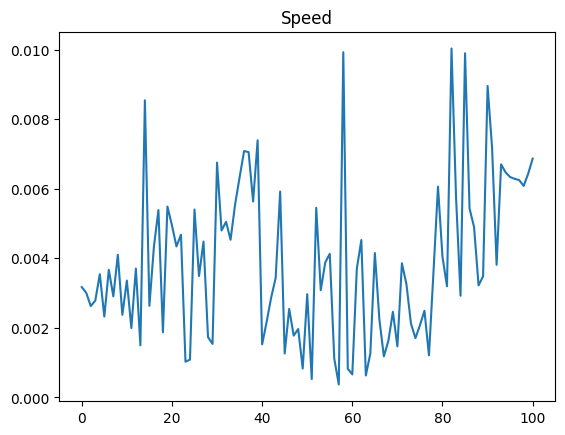

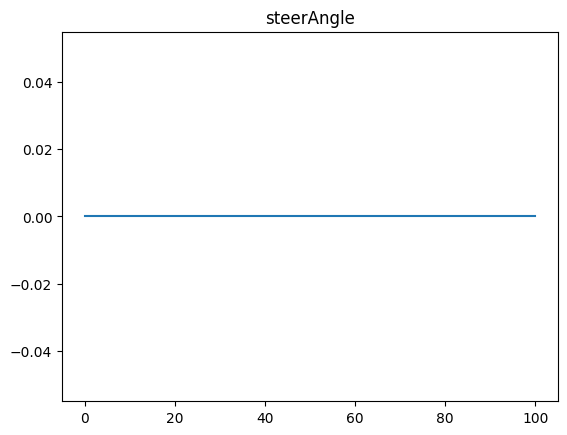

In [7]:
plt.title("Speed")
plt.plot(df.speed)
plt.show()

plt.title("steerAngle")
plt.plot(df.steerAngle)
plt.show()